In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import os

In [17]:
models_dir = "/shared/pkaduban/models"
omni_parser_model_dir = os.path.join(models_dir, "OmniParser")

In [18]:
from util.utils import (
    get_som_labeled_img, 
    check_ocr_box, 
    get_caption_model_processor, 
    get_yolo_model, 
    predict_yolo, 
    remove_overlap_new,
    int_box_area,
    process_bboxes_for_captioning,
)
import torch
from ultralytics import YOLO
from PIL import Image
from typing import Union
import numpy as np


In [19]:

device = 'cpu'
# model_path=os.path.join(omni_parser_model_dir, 'icon_detect/model.safetensors') # this fails to load as safetensors is not supported for YOLO
model_path=os.path.join(omni_parser_model_dir, 'icon_detect_v1_5/model_v1_5.pt')

som_model = get_yolo_model(model_path)
# som_model.to(device)
# print('model to {}'.format(device))

In [20]:
som_model.device, type(som_model)

(device(type='cpu'), ultralytics.models.yolo.model.YOLO)

In [21]:
# Use this variable to switch model_name for the script.

model_name = "blip2"
# model_name = "florence2"

if model_name == "blip2":
    model_name_or_path=os.path.join(omni_parser_model_dir, "icon_caption_blip2")
elif model_name == "florence2":
    model_name_or_path=os.path.join(omni_parser_model_dir, "icon_caption_florence")
else:
    raise ValueError("Unsupported model name: {}".format(model_name))

In [22]:
# two choices for caption model: fine-tuned blip2 or florence2
import importlib
# import util.utils
# importlib.reload(utils)
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
caption_model_processor = get_caption_model_processor(
    model_name=model_name, 
    model_name_or_path=model_name_or_path, 
    device=device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]/shared/pkaduban/workplace/model_enablement/md-en-eid-6366107259/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Loading checkpoint shards: 100%|██████████| 2/2 [00:40<00:00, 20.20s/it]


In [23]:
caption_model_processor

{'model': Blip2ForConditionalGeneration(
   (vision_model): Blip2VisionModel(
     (embeddings): Blip2VisionEmbeddings(
       (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
     )
     (encoder): Blip2Encoder(
       (layers): ModuleList(
         (0-38): 39 x Blip2EncoderLayer(
           (self_attn): Blip2Attention(
             (dropout): Dropout(p=0.0, inplace=False)
             (qkv): Linear(in_features=1408, out_features=4224, bias=True)
             (projection): Linear(in_features=1408, out_features=1408, bias=True)
           )
           (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
           (mlp): Blip2MLP(
             (activation_fn): GELUActivation()
             (fc1): Linear(in_features=1408, out_features=6144, bias=True)
             (fc2): Linear(in_features=6144, out_features=1408, bias=True)
           )
           (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
         )
       )
     )
 

In [24]:
# reload utils
import importlib
import utils
importlib.reload(utils)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

# image_path = 'imgs/google_page.png'
# image_path = 'imgs/windows_home.png'
# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
# image_path = 'imgs/ios.png'
image_path = 'imgs/word.png'
# image_path = 'imgs/excel2.png'

image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
BOX_TRESHOLD = 0.05


image size: (1919, 1079)


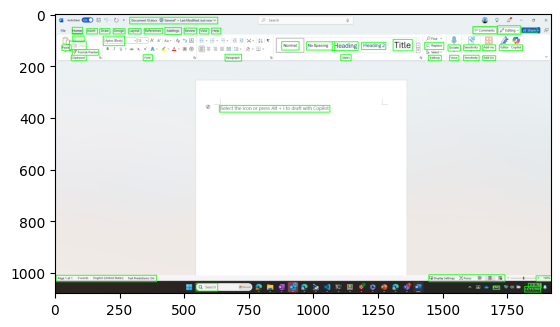

In [ ]:
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = True, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt

In [26]:
type(text), len(text), type(ocr_bbox), len(ocr_bbox)

(list, 45, list, 45)

In [27]:
text

['Document 10.docx  General*  Last Modified: Just now ',
 'Home',
 'Mailings',
 'Review',
 'Help',
 ' Comments',
 ' Editing ',
 'Insert',
 'Draw',
 'Design',
 'Layout',
 'References',
 'View',
 ' Share',
 'X Cut',
 'Aptos (Body)',
 'B Copy',
 'Normal',
 'No Spacing',
 'Heading',
 'Title',
 'Heading 2',
 ' Replace',
 'Paste',
 'Dictate',
 'Sensitivity',
 'Add-ins',
 'Editor Copilot',
 ' Format Painter',
 'Clipboard',
 'Font',
 ' Paragraph',
 'Styles',
 'Editing',
 'Voice',
 'Sensitivity',
 'Add-ins',
 'Select the icon or press Alt + i to draft with Copilot',
 'Page 1 of1 Owords English (United States) Text Predictions: On',
 'DisplaySettings Focus ',
 '+100%',
 'Q Search',
 '3:31 PM',
 'ENG',
 '11/11/2024']

In [28]:
type(ocr_bbox[0]), len(ocr_bbox[0])

(tuple, 4)

In [29]:
ocr_bbox[0], ocr_bbox[-1]

((288, 12, 340, 26), (1813, 1053, 62, 22))

In [30]:
# I need to separately run YOLO part and image captioning part so that I can understand
# input shapes for each differently. So I am breaking the implementation of get_som_labeled_img below
# as applicable for my usecase

def generate_filtered_boxes(
        image_rgb: Image.Image, 
        model=None, 
        BOX_TRESHOLD=0.01,
        ocr_bbox=None, 
        ocr_text=[], 
        iou_threshold=0.9,
        scale_img=False, 
        imgsz=None):
    """Process either an image path or Image object
    
    Args:
        image_source: Either a file path (str) or PIL Image object
        ...
    """
    w, h = image_rgb.size
    if not imgsz:
        imgsz = (h, w)
    # print('image size:', w, h)
    xyxy, logits, phrases = predict_yolo(model=model, image=image_rgb, box_threshold=BOX_TRESHOLD, imgsz=imgsz, scale_img=scale_img, iou_threshold=0.1)
    xyxy = xyxy / torch.Tensor([w, h, w, h]).to(xyxy.device)
    image_rgb = np.asarray(image_rgb)
    phrases = [str(i) for i in range(len(phrases))]

    # annotate the image with labels
    if ocr_bbox:
        ocr_bbox = torch.tensor(ocr_bbox) / torch.Tensor([w, h, w, h])
        ocr_bbox=ocr_bbox.tolist()
    else:
        print('no ocr bbox!!!')
        ocr_bbox = None

    ocr_bbox_elem = [{'type': 'text', 'bbox':box, 'interactivity':False, 'content':txt, 'source': 'box_ocr_content_ocr'} for box, txt in zip(ocr_bbox, ocr_text) if int_box_area(box, w, h) > 0] 
    xyxy_elem = [{'type': 'icon', 'bbox':box, 'interactivity':True, 'content':None} for box in xyxy.tolist() if int_box_area(box, w, h) > 0]
    filtered_boxes = remove_overlap_new(boxes=xyxy_elem, iou_threshold=iou_threshold, ocr_bbox=ocr_bbox_elem)
    
    # sort the filtered_boxes so that the one with 'content': None is at the end, and get the index of the first 'content': None
    filtered_boxes_elem = sorted(filtered_boxes, key=lambda x: x['content'] is None)
    # get the index of the first 'content': None
    starting_idx = next((i for i, box in enumerate(filtered_boxes_elem) if box['content'] is None), -1)
    filtered_boxes = torch.tensor([box['bbox'] for box in filtered_boxes_elem])
    print('len(filtered_boxes):', len(filtered_boxes), starting_idx)
    return filtered_boxes, logits, starting_idx, filtered_boxes_elem

filtered_boxes, logits, starting_idx, filtered_boxes_elem = generate_filtered_boxes(
    image_rgb=image_rgb, 
    model=som_model, 
    BOX_TRESHOLD=BOX_TRESHOLD, 
    ocr_bbox=ocr_bbox, 
    ocr_text=text, 
    iou_threshold=0.9, 
    scale_img=False)



0: 736x1280 115 icons, 572.2ms
Speed: 23.4ms preprocess, 572.2ms inference, 31.5ms postprocess per image at shape (1, 3, 736, 1280)
len(filtered_boxes): 155 41


In [31]:
croped_pil_image = process_bboxes_for_captioning(filtered_boxes, starting_idx, image_source=np.asarray(image_rgb))

In [32]:
len(croped_pil_image)

114

In [33]:
type(croped_pil_image[0]), croped_pil_image[0].size

(PIL.Image.Image, (64, 64))

In [26]:
save_dir_root = "/shared/pkaduban/experiments/OmniParser/cpu_goldens"

In [27]:
img_file_name, _ = os.path.splitext(os.path.basename(image_path))
img_file_name

'word'

In [ ]:
save_dir = os.path.join(save_dir_root, 'image_' + img_file_name, 'bounding_box_crops')
os.makedirs(save_dir, exist_ok=True)
for i, croped_img in enumerate(croped_pil_image):
    croped_img.save(os.path.join(save_dir, f"bbox_{i}.png"))

In [46]:
def save_yolo_outputs_to_disk(image_path):
    img_file_name, _ = os.path.splitext(os.path.basename(image_path))
    save_dir_root = "/shared/pkaduban/experiments/hf_top_20/OmniParser/cpu_goldens"
    save_dir = os.path.join(save_dir_root, 'image_' + img_file_name, 'bounding_box_crops')
    os.makedirs(save_dir, exist_ok=True)
    image = Image.open(image_path)
    image_rgb = image.convert('RGB')
    print(f'image file name: {img_file_name}, size: {image.size}')
    ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = False, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
    text, ocr_bbox = ocr_bbox_rslt  
    filtered_boxes, logits, starting_idx, filtered_boxes_elem = generate_filtered_boxes(
        image_rgb=image_rgb, 
        model=som_model, 
        BOX_TRESHOLD=BOX_TRESHOLD, 
        ocr_bbox=ocr_bbox, 
        ocr_text=text, 
        iou_threshold=0.9, 
        scale_img=False)
    croped_pil_image = process_bboxes_for_captioning(filtered_boxes, starting_idx, image_source=np.asarray(image_rgb))
    for i, croped_img in enumerate(croped_pil_image):
        croped_img.save(os.path.join(save_dir, f"bbox_{i}.png"))
    

In [42]:
img_paths = os.listdir('imgs/')
img_paths

['demo_image_som.jpg',
 'header_bar_thin.png',
 'windows.png',
 'saved_image_demo.png',
 'omni3.jpg',
 'google_page.png',
 'mobile.png',
 'ios.png',
 'windows_multitab.png',
 'omniparsericon.png',
 'windows_vm.png',
 'word.png',
 'header_bar.png',
 'onenote.png',
 'excel.png',
 'demo_image.jpg',
 'som_overlaid_omni.png',
 'omniboxicon.png',
 'windows_home.png',
 'logo.png',
 'gradioicon.png',
 'teams.png']

In [43]:
len(img_paths)

22

In [44]:
img_paths.remove('demo_image_som.jpg') # a demo of a result and we don't want to process it
img_paths.remove('saved_image_demo.png') # seems to be same as word.png
img_paths.remove('word.png') # already processed

img_paths.remove('header_bar_thin.png') # paddleocr returns empty result causing a NoneType error in check_ocr_box

len(img_paths)

18

In [51]:
for img_path in img_paths:
    print('processing image:', img_path)
    try:
        save_yolo_outputs_to_disk(os.path.join('imgs', img_path))
    except Exception as e:
        print(f'Error processing image {img_path}: {e}')
        continue
    finally:
        print ('----------------------------------')


processing image: windows.png
image file name: windows, size: (1280, 800)



0: 800x1280 22 icons, 353.8ms
Speed: 3.6ms preprocess, 353.8ms inference, 0.9ms postprocess per image at shape (1, 3, 800, 1280)
len(filtered_boxes): 26 12
----------------------------------
processing image: omni3.jpg
image file name: omni3, size: (1024, 768)

0: 960x1280 53 icons, 434.0ms
Speed: 5.6ms preprocess, 434.0ms inference, 1.2ms postprocess per image at shape (1, 3, 960, 1280)
len(filtered_boxes): 56 24
----------------------------------
processing image: google_page.png
image file name: google_page, size: (3239, 2159)

0: 864x1280 51 icons, 402.7ms
Speed: 6.6ms preprocess, 402.7ms inference, 1.1ms postprocess per image at shape (1, 3, 864, 1280)
len(filtered_boxes): 52 21
----------------------------------
processing image: mobile.png
image file name: mobile, size: (2360, 1640)

0: 896x1280 76 icons, 407.4ms
Speed: 6.5ms preprocess, 407.4ms inference, 1.1ms postprocess per image at shape (1, 3, 896, 1280)
len(filtered_boxes): 97 48
----------------------------------
proces

In [40]:
image_path = 'imgs/header_bar_thin.png'
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = True, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt
type(text), len(text), type(ocr_bbox), len(ocr_bbox)

TypeError: 'NoneType' object is not iterable

In [37]:
dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(image_path, som_model, BOX_TRESHOLD = BOX_TRESHOLD, output_coord_in_ratio=True, ocr_bbox=ocr_bbox,draw_bbox_config=draw_bbox_config, caption_model_processor=caption_model_processor, ocr_text=text,use_local_semantics=True, iou_threshold=0.7, scale_img=False, batch_size=128)


0: 736x1280 115 icons, 295.9ms
Speed: 4.6ms preprocess, 295.9ms inference, 1.1ms postprocess per image at shape (1, 3, 736, 1280)
len(filtered_boxes): 155 41


Expanding inputs for image tokens in BLIP-2 should be done in processing. Please follow instruction here (https://gist.github.com/zucchini-nlp/e9f20b054fa322f84ac9311d9ab67042) to update your BLIP-2 model. Using processors without these attributes in the config is deprecated and will throw an error in v4.50.


time to get parsed content: 660.8067212104797


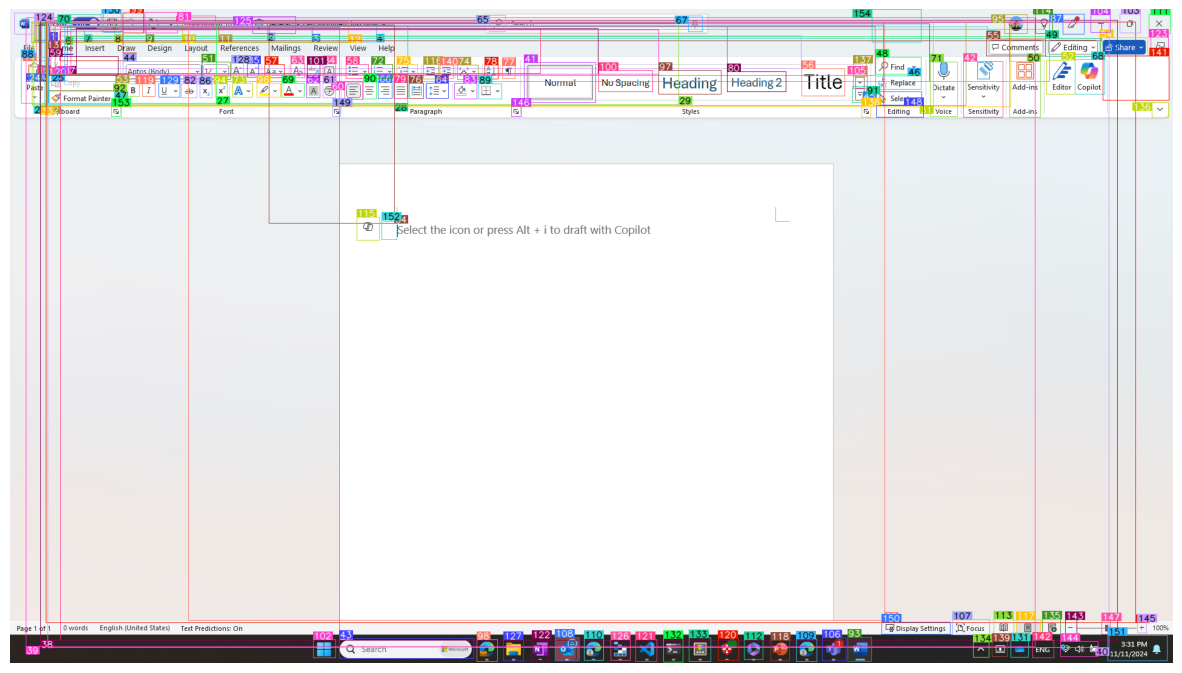

In [38]:
# plot dino_labled_img it is in base64
import base64
import matplotlib.pyplot as plt
import io
plt.figure(figsize=(15,15))

image = Image.open(io.BytesIO(base64.b64decode(dino_labled_img)))
plt.axis('off')

plt.imshow(image)
# print(len(parsed_content_list))


In [40]:
import pandas as pd
df = pd.DataFrame(parsed_content_list)
df['ID'] = range(len(df))

df

,type,bbox,interactivity,content,source,ID
0,text,"[0.1500781625509262, 0.011121409013867378, 0.1...",False,Document 10.docx General* Last Modified: Jus...,box_ocr_content_ocr,0
1,text,"[0.034392911940813065, 0.04726598784327507, 0....",False,Home,box_ocr_content_ocr,1
2,text,"[0.22094841301441193, 0.048192769289016724, 0....",False,Mailings,box_ocr_content_ocr,2
3,text,"[0.2595101594924927, 0.05004633963108063, 0.02...",False,Review,box_ocr_content_ocr,3
4,text,"[0.31474727392196655, 0.05004633963108063, 0.0...",False,Help,box_ocr_content_ocr,4
...,...,...,...,...,...,...
150,icon,"[0.7498565316200256, 0.9372018575668335, 0.808...",True,The image shows a display settings menu.,box_yolo_content_yolo,150
151,icon,"[0.9438579678535461, 0.9580966234207153, 0.995...",True,The image shows the time 31:11 PM on 11/11/2021.,box_yolo_content_yolo,151
152,icon,"[0.3195073902606964, 0.32292047142982483, 0.33...",True,The image shows a horizontal scroll bar.,box_yolo_content_yolo,152
153,icon,"[0.08737808465957642, 0.14849551022052765, 0.0...",True,The image shows an arrow pointing to the right.,box_yolo_content_yolo,153


In [15]:
parsed_content_list

[{'type': 'text',
  'bbox': [0.1500781625509262,
   0.011121409013867378,
   0.3272537887096405,
   0.03521779552102089],
  'interactivity': False,
  'content': 'Document 10.docx  General*  Last Modified: Just now ',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.034392911940813065,
   0.04726598784327507,
   0.05523710325360298,
   0.07228915393352509],
  'interactivity': False,
  'content': 'Home',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.22094841301441193,
   0.048192769289016724,
   0.2542991042137146,
   0.07321593910455704],
  'interactivity': False,
  'content': 'Mailings',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.2595101594924927,
   0.05004633963108063,
   0.2845231890678406,
   0.07136237621307373],
  'interactivity': False,
  'content': 'Review',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.31474727392196655,
   0.05004633963108063,
   0.3335070312023163,
   0.07136237621307373],
  